# BCO-DMO data

Similar to chlorophyll data on BCO-DMO, the key word 'CDOM' was searched on the website and all results were combed through and processed. This manual methods means that most likely the CDOM data here is not a comprehensive compilation of all CDOM data on BCO-DMO, but rather a compilation of the well documented, clearly labeled, and easily accessible CDOM data. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker

In [ ]:
GoMX1 = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\CDOM\BCO-DMO\bottle_data.xlsx')
GoMX1['time_utc'] = [f"{int(t):04d}" for t in GoMX1['time_utc']]  #for every row in mtime pad with 0 unitl it's 4 numbers long (HH:mm) (i'm getting rid of seconds fyi)
GoMX1 = GoMX1.rename(columns={'year_utc': 'year','month_utc': 'month','day_utc': 'day',})
GoMX1['hour'] = [int(t[:2]) for t in GoMX1['time_utc']]
GoMX1['minute'] = [int(t[2:4]) for t in GoMX1['time_utc']]
GoMX1['datetime']= pd.to_datetime(GoMX1[['year', 'month', 'day', 'hour', 'minute']]) #datetime variable
GoMX1 = GoMX1[['datetime','lat', 'lon', 'depth','cruiseid', 'CDOM','turbidity']]
GoMX1['experiment']='GoMX - DHOS'
GoMX1['source']='BCO-DMO'
GoMX1['investigators']='Samantha B. Joye'
GoMX1['affiliations']='University of Georgia'
GoMX1['url']='https://www.bco-dmo.org/dataset/3727'


GoMX2 = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\CDOM\BCO-DMO\AT18-02_CTD.xlsx')
GoMX2['time_start_utc'] = [f"{int(t):04d}" for t in GoMX2['time_start_utc']] 
GoMX2['hour'] = [int(t[:2]) for t in GoMX2['time_start_utc']]
GoMX2['minute'] = [int(t[2:4]) for t in GoMX2['time_start_utc']]
GoMX2['datetime'] =pd.to_datetime(GoMX2['date_start_utc'].dt.date.astype(str)+ ' ' +GoMX2['hour'].astype(str)+ ':' +GoMX2['minute'].astype(str), format='%Y-%m-%d %H:%M')
GoMX2 = GoMX2[['datetime','lat', 'lon', 'depth', 'CDOM','turbidity']]
GoMX2['experiment']='GoMX - DHOS'
GoMX2['source']='BCO-DMO'
GoMX2['investigators']='Samantha B. Joye'
GoMX2['affiliations']='University of Georgia'
GoMX2['url']='https://www.bco-dmo.org/dataset/3728'

GoMX3 = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\CDOM\BCO-DMO\WS1010_CTD.xlsx')
GoMX3['time_utc'] = [f"{int(t):04d}" for t in GoMX3['time_utc']]  #for every row in mtime pad with 0 unitl it's 4 numbers long (HH:mm) (i'm getting rid of seconds fyi)
GoMX3 = GoMX3.rename(columns={'month_utc': 'month','day_utc': 'day',})
GoMX3['hour'] = [int(t[:2]) for t in GoMX3['time_utc']]
GoMX3['minute'] = [int(t[2:4]) for t in GoMX3['time_utc']]
GoMX3['datetime']= pd.to_datetime(GoMX3[['year', 'month', 'day', 'hour', 'minute']]) #datetime variable
GoMX3 = GoMX3[['datetime','lat', 'lon', 'depth', 'CDOM']]
GoMX3['experiment']='GoMX - DHOS'
GoMX3['source']='BCO-DMO'
GoMX3['investigators']='Samantha B. Joye'
GoMX3['affiliations']='University of Georgia'
GoMX3['url']='https://www.bco-dmo.org/dataset/3729'

nerissa = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\CDOM\BCO-DMO\Nerissa_CTD.xlsx')
nerissa['Time'] = [f"{int(t):04d}" for t in nerissa['Time']] 
nerissa['Date'] = nerissa['Date'].astype(str)
nerissa['month'] = [int(t[4:6]) for t in nerissa['Date']]
nerissa['day'] = [int(t[6:8]) for t in nerissa['Date']]
nerissa['year'] = [int(t[0:4]) for t in nerissa['Date']]
nerissa['hour'] = [int(t[:2]) for t in nerissa['Time']]
nerissa['minute'] = [int(t[2:4]) for t in nerissa['Time']]
nerissa['datetime']= pd.to_datetime(nerissa[['year', 'month', 'day', 'hour', 'minute']]) #datetime variable
nerissa = nerissa.rename(columns={'Latitude': 'lat','Longitude': 'lon','Depth':'depth',})
nerissa = nerissa[['datetime','lat', 'lon', 'depth', 'CDOM','Station_ID']]
nerissa['experiment']='SoCalPlumeEx2012'
nerissa['source']='BCO-DMO'
nerissa['investigators']='Raphael M. Kudela'
nerissa['affiliations']='University of California-Santa Cruz'
nerissa['url']='https://www.bco-dmo.org/dataset/537627'

yfin= pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\CDOM\BCO-DMO\YellowFin_CTD.xlsx')
yfin['Date'] = yfin['Date'].astype(str)
yfin['month'] = [int(t[4:6]) for t in yfin['Date']]
yfin['day'] = [int(t[6:8]) for t in yfin['Date']]
yfin['year'] = [int(t[0:4]) for t in yfin['Date']]
yfin['datetime']= pd.to_datetime(yfin[['year', 'month', 'day']]) #datetime variable
yfin = yfin.rename(columns={'Latitude': 'lat','Longitude': 'lon','Depth':'depth','Turbidity':'turbidity'})
yfin = yfin[['datetime','lat', 'lon', 'depth', 'CDOM','turbidity','Station_ID']]
yfin['experiment']='SoCalPlumeEx2012'
yfin['source']='BCO-DMO'
yfin['investigators']='Raphael M. Kudela'
yfin['affiliations']='University of California-Santa Cruz'
yfin['url']='https://www.bco-dmo.org/dataset/537818'

GoMX4= pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\CDOM\BCO-DMO\discrete_samples_concat.xlsx')
GoMX4['Date'] = GoMX4['Date'].astype(str)
GoMX4['Time'] = GoMX4['Time'].astype(str)
GoMX4['datetime'] = pd.to_datetime(GoMX4['Date'] + ' ' + GoMX4['Time'])
GoMX4 = GoMX4.rename(columns={'Latitude':'lat','Longitude':'lon','Turbidity':'turbidity','Cruise':'cruiseid','Station':'Station_ID',
                              'Sample_Depth':'depth','wetCDOM':'CDOM'})
GoMX4 = GoMX4[['datetime','lat', 'lon', 'depth', 'CDOM','turbidity','Station_ID','cruiseid']]
GoMX4['experiment']='nGOMx acidification'
GoMX4['source']='BCO-DMO'
GoMX4['investigators']='Wei-Jun Cai'
GoMX4['affiliations']='University of Delaware'
GoMX4['url']='https://www.bco-dmo.org/dataset/772513'

reu_oto = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\CDOM\BCO-DMO\combined.xlsx')
reu_oto = reu_oto.rename(columns={'date_time': 'datetime','Water_Depth':'depth','Latitude':'lat','Longitude': 'lon','Station':'Station_ID'})
reu_oto = reu_oto[['datetime','lat', 'lon', 'depth', 'CDOM','Station_ID']]
reu_oto['experiment']='REU-OTO'
reu_oto['source']='BCO-DMO'
reu_oto['investigators']='Lisa Campbell'
reu_oto['affiliations']='Texas A&M University'
reu_oto['url']='https://www.bco-dmo.org/dataset/753882'

#scanfish: i deleted some columns from the raw xlsx dataset just so that it takes up less room 
scanfish = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\CDOM\BCO-DMO\scanfish_opc.xlsx')
scanfish['datetime']= pd.to_datetime(scanfish['ISO_DateTime_UTC']) #datetime variable
scanfish = scanfish[['datetime','lat', 'lon', 'depth', 'CDOM']]
scanfish['experiment']='GoMX - DHOS'
scanfish['source']='BCO-DMO'
scanfish['investigators']=' Michael R. Roman'
scanfish['affiliations']='University of Maryland Center for Environmental Science'
scanfish['url']='https://www.bco-dmo.org/dataset/746081'

harvey = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\CDOM\BCO-DMO\oct_2017_discrete.xlsx')
harvey['datetime']= pd.to_datetime(harvey['DateTime']) #datetime variable
harvey = harvey.rename(columns={'Cruise':'cruiseid','Depth':'depth','Latitude':'lat','Longitude': 'lon','Station':'Station_ID',
                                'wetCDOM':'CDOM','Turbidity':'turbidity'})
harvey = harvey[['datetime','lat', 'lon', 'depth', 'CDOM','turbidity','Station_ID','cruiseid']]
harvey['experiment']='HarveyCarbonCycle'
harvey['source']='BCO-DMO'
harvey['investigators']='Brian Roberts'
harvey['affiliations']='Louisiana Universities Marine Consortium'
harvey['url']='https://www.bco-dmo.org/dataset/844721'

hrr=pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\CDOM\BCO-DMO\HRR_ctd_2017.xlsx')
hrr['datetime']= pd.to_datetime(hrr['ISO_DateTime_UTC']) #datetime variable
hrr = hrr.rename(columns={'wetCDOM':'CDOM','depSM':'depth','lat_decdeg':'lat','lon_decdeg': 'lon','station':'Station_ID'})
hrr = hrr[['datetime','lat', 'lon', 'depth', 'CDOM','Station_ID']]
hrr['experiment']='RAPID HRR'
hrr['source']='BCO-DMO'
hrr['investigators']='Lisa Campbell'
hrr['affiliations']='Texas A&M University'
hrr['url']='https://www.bco-dmo.org/dataset/809428'

rapid=pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\CDOM\BCO-DMO\CTD.xlsx')
rapid['datetime']= pd.to_datetime(rapid['Start_ISO_DateTime_UTC']) #datetime variable
rapid = rapid.rename(columns={'Cruise_ID':'cruiseid','Station':'Station_ID','Depth': 'depth','Latitude':'lat','Longitude': 'lon',
                              'Fluorescence_WET_CDOM':'CDOM'})
rapid = rapid[['datetime','lat', 'lon', 'depth', 'CDOM','Station_ID','cruiseid']]
rapid['experiment']='RAPID Plankton'
rapid['source']='BCO-DMO'
rapid['investigators']='Beth Stauffer'
rapid['affiliations']='University of Louisiana at Lafayette'
rapid['url']='https://www.bco-dmo.org/dataset/827969'

Once all dataframes were organized, they were all concatinated onto the same dataframe and only the sample taken in North America were kept. 

In [ ]:
dfs=[GoMX1,GoMX2,GoMX3,nerissa,yfin,GoMX4,reu_oto,scanfish,harvey,hrr,rapid]
bcodmo_cdom = pd.concat(dfs).reset_index(drop=True)
bcodmo_cdom = bcodmo_cdom.replace('nd', np.nan)
bcodmo_cdom = bcodmo_cdom[bcodmo_cdom['depth'] <=150] 
bcodmo_cdom = bcodmo_cdom.dropna(how='all', subset=['CDOM', 'turbidity'])
bcodmo_cdom = bcodmo_cdom.rename(columns={'CDOM':'cdom','cruiseid':'cruise','Station_ID':'station'})
bcodmo_cdom['datetime']= pd.to_datetime(bcodmo_cdom['datetime'],utc=True) #datetime variable
bcodmo_cdom['datetime'] = bcodmo_cdom['datetime'].dt.tz_localize(None)

shp = gpd.read_file(r'C:\Users\gianna.milton\Documents\Python\Shapefiles\combined_coastline.shp')
gdf = gpd.GeoDataFrame(bcodmo_cdom, geometry=gpd.points_from_xy(bcodmo_cdom.lon, bcodmo_cdom.lat), crs="EPSG:4269")
gdf = gdf.to_crs(shp.crs)
bcodmo_cdom = gpd.sjoin(gdf, shp, how="inner", predicate="within")
columns_to_drop = ['geometry', 'index_right', 'merge_id']
bcodmo_cdom = bcodmo_cdom.drop(columns=columns_to_drop)
bcodmo_cdom= bcodmo_cdom.reset_index(drop=True)

## Plots 

In [2]:
bcodmo = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\bco_dmo_cdom_qc.xlsx')


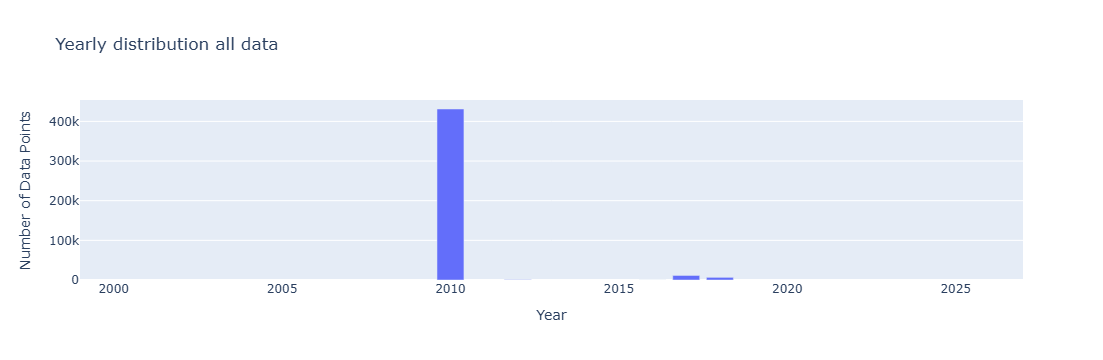

In [3]:
year_test=bcodmo.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(grouped,x='year', y='DataPoints', title='Yearly distribution all data',
             labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

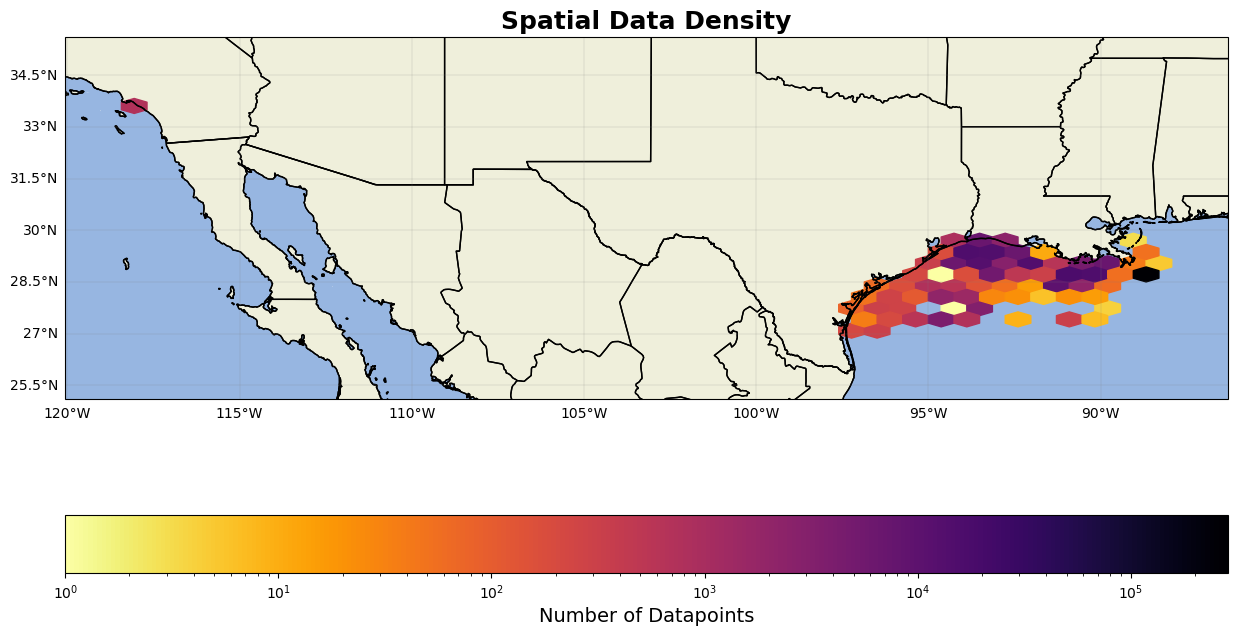

In [7]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(year_test.lon, year_test.lat, gridsize=(40,10), cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='horizontal')#, pad=0.02, shrink=0.8)
cb.set_label('Number of Datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_xlim(min(year_test.lon)-2,max(year_test.lon)+2)
ax.set_ylim(min(year_test.lat)-2,max(year_test.lat)+2)

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()